### 🧠 Hyperparameter Tuning using **Optuna** – Super Simple & Powerful

---

Optuna is a fast, flexible, and scalable optimization framework for **automated hyperparameter search**.
It uses intelligent search strategies like **Tree-structured Parzen Estimator (TPE)** to find the best hyperparameters.

---

## ✅ Key Features

* Efficient (Bayesian optimization using TPE)
* Pruning of bad trials early
* Easy to use with **Scikit-learn**, **XGBoost**, **LightGBM**, etc.

---

## 🔧 Installation

```bash
pip install optuna
```

---

## 🔹 Step-by-step Example (with XGBoost)

Let’s tune hyperparameters of an **XGBoost classifier** using Optuna.

---

### 🔸 1. Define the Objective Function

This function:

* Suggests hyperparameters
* Trains the model
* Returns the **score to minimize/maximize**

```python
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)

def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'booster': 'gbtree',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
    }

    model = xgb.XGBClassifier(**param, use_label_encoder=False)
    score = cross_val_score(model, X, y, cv=3, scoring='accuracy')
    return score.mean()
```

---

### 🔸 2. Run the Optimization

```python
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
```

---

### 🔸 3. Best Parameters & Score

```python
print("Best hyperparameters:", study.best_params)
print("Best accuracy:", study.best_value)
```

---

## 📊 Optional: Visualize the Search

```python
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
```

---

## 💡 Tip

If you use LightGBM or CatBoost, they also support Optuna **natively**:

```python
import lightgbm as lgb
dtrain = lgb.Dataset(X, y)

# LightGBM + Optuna integration example
```

---

## 📦 Summary

| Feature            | Optuna                         |
| ------------------ | ------------------------------ |
| Algorithm          | TPE (Bayesian optimization)    |
| Pruning            | ✅ Yes                          |
| Parallelism        | ✅ Yes                          |
| Visualization      | ✅ Yes (`optuna.visualization`) |
| Works with XGBoost | ✅ Fully supported              |

---




Here’s a **head-to-head comparison** of `GridSearchCV` vs `Optuna` for hyperparameter tuning:

---

## ⚔️ GridSearchCV vs Optuna

| Feature                     | `GridSearchCV`               | `Optuna` (Bayesian Optimization)           |
| --------------------------- | ---------------------------- | ------------------------------------------ |
| 🔍 Search Strategy          | Exhaustive grid search       | Intelligent search (TPE, CMA-ES)           |
| 🚀 Speed                    | Very slow on large spaces    | Much faster — skips bad regions            |
| 📦 Sample Efficiency        | Wastes trials on bad configs | Efficient exploration                      |
| 🔁 Parallelization          | ✅ (but fixed param grid)     | ✅ (multi-threaded or distributed)          |
| ✂️ Early Stopping / Pruning | ❌ No                         | ✅ Yes — can stop unpromising trials early  |
| 📈 Visualization            | ❌ None                       | ✅ `optuna.visualization`                   |
| 🔢 Dynamic Search Space     | ❌ Fixed beforehand           | ✅ Can use `if` conditions and logic        |
| 🔧 Ease of Use              | Very simple for small grids  | Slightly more setup, but far more powerful |
| 📊 CV Support               | ✅ Built-in cross-validation  | ✅ You implement CV in the `objective()`    |
| 🧠 Learning Based?          | ❌ No                         | ✅ Learns from past trials (Bayesian)       |

---

## 🧪 When to Use What?

| Scenario                               | Recommendation |
| -------------------------------------- | -------------- |
| Small grid, limited combinations       | ✅ GridSearchCV |
| Large search space                     | ✅ Optuna       |
| Time/resource-constrained tuning       | ✅ Optuna       |
| Need intelligent pruning & parallelism | ✅ Optuna       |
| Simpler traditional pipelines          | ✅ GridSearchCV |

---

## 🧠 Intuition

### GridSearchCV:

```text
Try every possible combination (brute-force), even dumb ones.
```

### Optuna:

```text
Starts smart. Tries promising areas. Avoids bad ones using probability.
```

---

## 🧪 Tiny Visual Comparison

Let’s say we want to tune `learning_rate` between \[0.01, 0.3]:

* `GridSearchCV`: tries 0.01, 0.05, 0.1, 0.15, … even if 0.15 already sucks
* `Optuna`: starts with 0.05, sees 0.1 is better, then explores 0.08, 0.09, 0.11...

---

## 🔚 Final Verdict

* 🧠 Use **GridSearchCV** when the search space is tiny and well understood
* 🚀 Use **Optuna** for real-world tuning — it’s **faster, smarter, and scalable**

---



### 🎯 Definition: Hyperparameters

> **Hyperparameters** are the **external configuration settings** of a machine learning model that are **set before training begins** and **not learned from the data**.

They control the **training process** and **model structure**, like:

* How fast the model learns
* How complex the model is
* When training should stop
* How regularization is applied

---

## 🧠 Hyperparameters vs Parameters

|                    | **Hyperparameters**                  | **Parameters**                                 |
| ------------------ | ------------------------------------ | ---------------------------------------------- |
| Set by             | You (before training)                | Model (during training)                        |
| Learned from data? | ❌ No                                 | ✅ Yes                                          |
| Examples           | Learning rate, max depth, batch size | Weights in linear/logistic regression, neurons |
| Affects            | How model learns                     | What the model learns                          |

---

## 🔸 Examples of Hyperparameters by Algorithm

### 📘 Linear/Logistic Regression

* `C` (inverse of regularization strength)
* `penalty` (`l1`, `l2`, etc.)

### 📗 Decision Trees / Random Forest

* `max_depth`
* `min_samples_split`
* `n_estimators` (for ensemble methods)

### 📙 SVM (Support Vector Machine)

* `kernel` (`linear`, `rbf`, etc.)
* `C` (penalty term)
* `gamma` (for RBF kernel)

### 📕 KNN

* `n_neighbors`
* `distance metric` (`euclidean`, `manhattan`, etc.)

### 📒 Neural Networks

* `learning_rate`
* `batch_size`
* `epochs`
* `hidden_layer_sizes`
* `dropout rate`
* `optimizer` (`adam`, `sgd`)

---

## 🔧 Example: Logistic Regression

```python
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=0.1, penalty='l2', solver='liblinear')
```

* Here `C`, `penalty`, and `solver` are hyperparameters

---

## 🧪 Example: XGBoost

```python
from xgboost import XGBClassifier

model = XGBClassifier(learning_rate=0.05, max_depth=5, n_estimators=200)
```

| Hyperparameter  | Effect                             |
| --------------- | ---------------------------------- |
| `learning_rate` | Controls how fast the model learns |
| `max_depth`     | Maximum depth of each tree         |
| `n_estimators`  | Number of boosting rounds          |

---




GridSearchCV is a very costly method of hyperparameter tuning as we need to re-train the model again and again

### 🎯 **Bayesian Hyperparameter Search** — Smarter Tuning for ML Models

---

## 🧠 What is Bayesian Search?

> **Bayesian Search** is a hyperparameter optimization method that **builds a probabilistic model** of the objective function and uses it to **choose the next set of hyperparameters to evaluate**.

Unlike Grid or Random Search, which blindly explore, **Bayesian Search learns from previous trials** and focuses on **promising regions** of the search space.

---

## 🔍 Key Idea

1. Start with a few random hyperparameter configurations
2. Fit a **surrogate model** (e.g. Gaussian Process, TPE) to estimate performance
3. Use the surrogate to choose the **next best hyperparameters**
4. Repeat: improve the surrogate model with new results

---

## 📊 Intuition

Bayesian Search balances:

* **Exploration**: Try new regions of the hyperparameter space
* **Exploitation**: Focus on regions that already look promising

---

## 📦 Common Libraries

| Library           | Surrogate Method                       | Notes                               |
| ----------------- | -------------------------------------- | ----------------------------------- |
| `Optuna`          | TPE (Tree-structured Parzen Estimator) | Fast, supports pruning              |
| `scikit-optimize` | Gaussian Process (default)             | Simple API, integrates with sklearn |
| `Hyperopt`        | TPE                                    | Popular in early adoption           |
| `Ray Tune`        | Multiple backends                      | Distributed, scalable tuning        |

---

## 🧪 Example Using `Optuna`

```python
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 2, 20)
    n_estimators = trial.suggest_int('n_estimators', 10, 300)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    model = RandomForestClassifier(max_depth=max_depth,
                                   n_estimators=n_estimators,
                                   criterion=criterion)
    
    score = cross_val_score(model, X, y, cv=3).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(study.best_params)
```

---

## ✅ Pros

* Much **faster** than GridSearch on large spaces
* Learns and adapts during search
* Supports **pruning** of bad trials (e.g. in Optuna)
* Excellent for **expensive-to-evaluate models**

---

## ❌ Cons

* Harder to parallelize than random search
* Slightly more setup than `GridSearchCV`
* Surrogate model may get stuck in local optima

---

## 📌 Use When

| Situation             | Recommendation    |
| --------------------- | ----------------- |
| Many hyperparameters  | ✅ Use Bayesian    |
| Training is expensive | ✅ Use Bayesian    |
| Small search space    | ❌ Use Grid/Random |
| Want smart pruning    | ✅ Use Optuna      |

---




# 🔍 Bayesian Search for Hyperparameter Tuning

## 📋 Overview
Bayesian optimization is a **sequential model-based optimization** technique that uses probabilistic models to find optimal hyperparameters efficiently. Unlike grid search or random search, it learns from previous evaluations to make smarter decisions about which hyperparameters to try next.

---

## 🎯 Core Concept

### The Problem
Given a black-box function $f(\mathbf{x})$ representing model performance, we want to find:

$$\mathbf{x}^* = \arg\max_{\mathbf{x} \in \mathcal{X}} f(\mathbf{x})$$

where:
- $\mathbf{x}$ = hyperparameter configuration
- $\mathcal{X}$ = hyperparameter search space
- $f(\mathbf{x})$ = validation score (accuracy, F1, etc.)

### Key Challenges
- $f(\mathbf{x})$ is **expensive to evaluate** (requires full model training)
- $f(\mathbf{x})$ is **noisy** (validation scores vary)
- $f(\mathbf{x})$ has **no analytical form** (black-box)

---

## 🧠 Bayesian Optimization Framework

### Two Main Components

#### 1. **Surrogate Model** (Probabilistic Model)
Models the unknown objective function $f(\mathbf{x})$ using observed data:

$$\mathcal{D}_n = \{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), \ldots, (\mathbf{x}_n, y_n)\}$$

**Common Choices:**
- **Gaussian Process (GP)**: $f(\mathbf{x}) \sim \mathcal{GP}(\mu(\mathbf{x}), k(\mathbf{x}, \mathbf{x}'))$
- **Random Forest**
- **Bayesian Neural Networks**

#### 2. **Acquisition Function**
Decides which point to evaluate next by balancing:
- **Exploitation**: Areas with high predicted performance
- **Exploration**: Areas with high uncertainty

---

## 📊 Gaussian Process Surrogate

### Mathematical Foundation
A Gaussian Process defines a distribution over functions:

$$f(\mathbf{x}) \sim \mathcal{GP}(\mu(\mathbf{x}), k(\mathbf{x}, \mathbf{x}'))$$

where:
- $\mu(\mathbf{x})$ = mean function (often set to 0)
- $k(\mathbf{x}, \mathbf{x}')$ = covariance kernel

### Posterior Prediction
Given observations $\mathcal{D}_n$, the posterior at new point $\mathbf{x}^*$ is:

$$f(\mathbf{x}^*) | \mathcal{D}_n \sim \mathcal{N}(\mu_n(\mathbf{x}^*), \sigma_n^2(\mathbf{x}^*))$$

**Posterior Mean:**
$$\mu_n(\mathbf{x}^*) = \mathbf{k}^T(\mathbf{K} + \sigma_n^2\mathbf{I})^{-1}\mathbf{y}$$

**Posterior Variance:**
$$\sigma_n^2(\mathbf{x}^*) = k(\mathbf{x}^*, \mathbf{x}^*) - \mathbf{k}^T(\mathbf{K} + \sigma_n^2\mathbf{I})^{-1}\mathbf{k}$$

where:
- $\mathbf{k} = [k(\mathbf{x}^*, \mathbf{x}_1), \ldots, k(\mathbf{x}^*, \mathbf{x}_n)]^T$
- $\mathbf{K}_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$
- $\mathbf{y} = [y_1, \ldots, y_n]^T$

### Popular Kernels

**RBF (Radial Basis Function):**
$$k(\mathbf{x}, \mathbf{x}') = \sigma_f^2 \exp\left(-\frac{|\mathbf{x} - \mathbf{x}'|^2}{2\ell^2}\right)$$

**Matérn 5/2:**
$$k(\mathbf{x}, \mathbf{x}') = \sigma_f^2 \left(1 + \frac{\sqrt{5}r}{\ell} + \frac{5r^2}{3\ell^2}\right) \exp\left(-\frac{\sqrt{5}r}{\ell}\right)$$

---

## 🎯 Acquisition Functions

### 1. **Expected Improvement (EI)**
$$\text{EI}(\mathbf{x}) = \mathbb{E}[\max(f(\mathbf{x}) - f^+, 0)]$$

where $f^+ = \max_{i=1,\ldots,n} y_i$ is the best observed value.

**Analytical Form:**
$$\text{EI}(\mathbf{x}) = \sigma(\mathbf{x}) \left[ Z \Phi(Z) + \phi(Z) \right]$$

where:
- $Z = \frac{\mu(\mathbf{x}) - f^+ - \xi}{\sigma(\mathbf{x})}$
- $\xi \geq 0$ is the exploration parameter
- $\Phi(\cdot)$ and $\phi(\cdot)$ are CDF and PDF of standard normal

### 2. **Upper Confidence Bound (UCB)**
$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \beta \sigma(\mathbf{x})$$

where $\beta > 0$ controls exploration-exploitation trade-off.

**Theoretical Guarantee:**
$$\beta_t = \sqrt{2 \log(t^2 \pi^2 / 6\delta)}$$

provides regret bounds with probability $1-\delta$.

### 3. **Probability of Improvement (PI)**
$$\text{PI}(\mathbf{x}) = \Phi\left(\frac{\mu(\mathbf{x}) - f^+ - \xi}{\sigma(\mathbf{x})}\right)$$

### 4. **Entropy Search**
$$\text{ES}(\mathbf{x}) = H[p(\mathbf{x}^*)] - \mathbb{E}_{y|\mathbf{x}}[H[p(\mathbf{x}^*|y)]]$$

---

## 🔄 Bayesian Optimization Algorithm

```
Algorithm: Bayesian Optimization
Input: f (objective function), X (search space), n (budget)
Output: x* (best hyperparameter configuration)

1. Initialize with random samples D₀ = {(x₁, y₁), ..., (xₖ, yₖ)}
2. For t = k+1 to n:
   a. Fit surrogate model on Dₜ₋₁
   b. Optimize acquisition function: xₜ = argmax α(x|Dₜ₋₁)
   c. Evaluate: yₜ = f(xₜ)
   d. Augment data: Dₜ = Dₜ₋₁ ∪ {(xₜ, yₜ)}
3. Return x* = argmax{y₁, ..., yₙ} xᵢ
```

---

## 📈 Advantages vs Traditional Methods

| Method | Evaluations | Parallelization | Theoretical Guarantees |
|--------|-------------|----------------|----------------------|
| **Grid Search** | $\mathcal{O}(d^k)$ | Easy | None |
| **Random Search** | Independent | Easy | Convergence |
| **Bayesian Opt** | $\mathcal{O}(\log n)$ | Harder | Regret bounds |

### Key Benefits
- **Sample Efficiency**: Requires fewer function evaluations
- **Principled Uncertainty**: Quantifies model uncertainty
- **Automatic Trade-off**: Balances exploration/exploitation
- **Handles Noise**: Robust to noisy evaluations

---

## 🛠️ Implementation Considerations

### Hyperparameter Space Design
```python
# Example search space
search_space = {
    'learning_rate': Real(1e-6, 1e-1, prior='log-uniform'),
    'n_estimators': Integer(10, 1000),
    'max_depth': Integer(1, 32),
    'regularization': Categorical(['l1', 'l2', 'elastic_net'])
}
```

### Acquisition Function Selection
- **EI**: Good general purpose, handles exploitation well
- **UCB**: Better for high-dimensional problems
- **PI**: Simple but can be too greedy
- **ES**: Best for finding global optimum

### Practical Tips
1. **Normalization**: Scale hyperparameters to [0,1] or standardize
2. **Warm Start**: Initialize with good prior knowledge
3. **Early Stopping**: Use validation curves to avoid overfitting
4. **Multi-fidelity**: Use cheap approximations (fewer epochs, smaller datasets)

---

## 🔬 Advanced Variants

### 1. **Multi-objective Bayesian Optimization**
Optimize multiple objectives simultaneously:
$$\mathbf{f}(\mathbf{x}) = [f_1(\mathbf{x}), f_2(\mathbf{x}), \ldots, f_m(\mathbf{x})]$$

**Pareto Front**: Set of non-dominated solutions

### 2. **Constrained Bayesian Optimization**
Include constraints $g_i(\mathbf{x}) \leq 0$:
$$\text{Constrained EI}(\mathbf{x}) = \text{EI}(\mathbf{x}) \cdot \prod_{i=1}^m P(g_i(\mathbf{x}) \leq 0)$$

### 3. **Multi-fidelity Optimization**
Use approximations with different computational costs:
- **Hyperband**: Successive halving with multiple budgets
- **BOHB**: Combines Hyperband with Bayesian optimization
- **Freeze-Thaw**: Pause and resume training

---

## 📊 Performance Metrics

### Regret Analysis
**Simple Regret**: $r_n = f(\mathbf{x}^*) - \max_{i=1,\ldots,n} f(\mathbf{x}_i)$

**Cumulative Regret**: $R_n = \sum_{i=1}^n (f(\mathbf{x}^*) - f(\mathbf{x}_i))$

### Convergence Rates
For GP-based Bayesian optimization:
- **UCB**: $\mathcal{O}(\sqrt{n \log n})$ cumulative regret
- **EI**: $\mathcal{O}(\sqrt{n \log n})$ simple regret

---

## 🧮 Popular Libraries

### Scikit-Optimize
```python
from skopt import gp_minimize
from skopt.space import Real, Integer

# Define objective function
def objective(params):
    lr, n_est = params
    model = RandomForestRegressor(n_estimators=n_est)
    return -cross_val_score(model, X, y).mean()

# Optimize
result = gp_minimize(
    func=objective,
    dimensions=[Real(1e-6, 1e-1, prior='log-uniform'),
                Integer(10, 1000)],
    n_calls=50,
    acquisition_func='EI'
)
```

### Optuna
```python
import optuna

def objective(trial):
    lr = trial.suggest_float('lr', 1e-6, 1e-1, log=True)
    n_est = trial.suggest_int('n_estimators', 10, 1000)
    # ... train model and return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
```

---

## 🎯 Best Practices

### 1. **Problem Setup**
- Define clear objective function
- Set appropriate search bounds
- Include validation strategy in objective

### 2. **Acquisition Function Tuning**
- Start with EI ($\xi = 0.01$)
- Increase $\xi$ for more exploration
- Use UCB for high-dimensional problems

### 3. **Computational Efficiency**
- Use early stopping in objective function
- Implement checkpointing for long runs
- Consider multi-fidelity approaches

### 4. **Diagnostics**
- Plot acquisition function evolution
- Monitor convergence curves
- Validate on held-out test set

---

## 🔍 Key Takeaways

- **Bayesian optimization** is the gold standard for expensive hyperparameter tuning
- **Gaussian Processes** provide principled uncertainty quantification
- **Acquisition functions** automatically balance exploration vs exploitation
- **Sample efficiency** is the main advantage over grid/random search
- **Implementation** requires careful consideration of search space design
- **Advanced variants** handle multi-objective, constrained, and multi-fidelity scenarios

---

*💡 Remember: Bayesian optimization shines when function evaluations are expensive (model training), but may be overkill for cheap functions where random search suffices.*

### Optuna

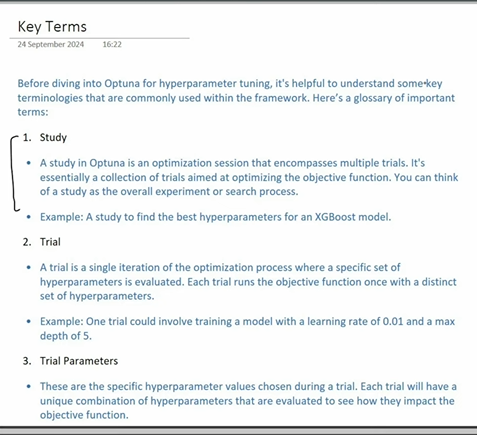

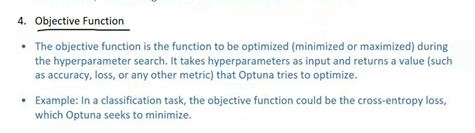

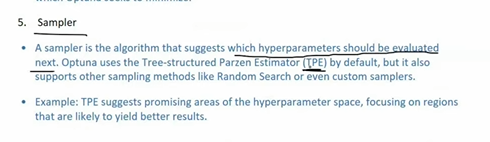

In [1]:
# Import necessary libraries
import optuna
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Pima Indian Diabetes dataset from sklearn
# Note: Scikit-learn's built-in 'load_diabetes' is a regression dataset.
# We will load the actual diabetes dataset from an external source
import pandas as pd

# Load the Pima Indian Diabetes dataset (from UCI repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the dataset
df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
import numpy as np

# Replace zero values with NaN in columns where zero is not a valid value
cols_with_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing_vals] = df[cols_with_missing_vals].replace(0, np.nan)

# Impute the missing values with the mean of the respective column
df.fillna(df.mean(), inplace=True)

# Check if there are any remaining missing values
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [3]:
# Split into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check the shape of the data
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')


Training set shape: (537, 8)
Test set shape: (231, 8)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [5]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters


[I 2025-07-07 22:49:13,135] A new study created in memory with name: no-name-50f1acf6-334c-4fa7-93c8-09ce816eeef9
[I 2025-07-07 22:49:13,422] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 113, 'max_depth': 5}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-07-07 22:49:13,763] Trial 1 finished with value: 0.7597765363128491 and parameters: {'n_estimators': 153, 'max_depth': 4}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-07-07 22:49:14,157] Trial 2 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 158, 'max_depth': 17}. Best is trial 2 with value: 0.7728119180633147.
[I 2025-07-07 22:49:14,628] Trial 3 finished with value: 0.7746741154562384 and parameters: {'n_estimators': 188, 'max_depth': 18}. Best is trial 3 with value: 0.7746741154562384.
[I 2025-07-07 22:49:15,118] Trial 4 finished with value: 0.7765363128491619 and parameters: {'n_estimators': 198, 'max_depth': 18}. Best is trial 4 with value: 0.776536

In [6]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7858472998137803
Best hyperparameters: {'n_estimators': 121, 'max_depth': 15}


In [7]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.76


## Samplers in Optuna

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [9]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

[I 2025-07-07 22:50:25,772] A new study created in memory with name: no-name-26132e26-90c7-4ee0-ba5b-7136c05e9361
[I 2025-07-07 22:50:26,204] Trial 0 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 174, 'max_depth': 20}. Best is trial 0 with value: 0.7728119180633147.
[I 2025-07-07 22:50:26,340] Trial 1 finished with value: 0.7765363128491621 and parameters: {'n_estimators': 58, 'max_depth': 5}. Best is trial 1 with value: 0.7765363128491621.
[I 2025-07-07 22:50:26,623] Trial 2 finished with value: 0.7802607076350093 and parameters: {'n_estimators': 115, 'max_depth': 18}. Best is trial 2 with value: 0.7802607076350093.
[I 2025-07-07 22:50:27,037] Trial 3 finished with value: 0.7635009310986964 and parameters: {'n_estimators': 172, 'max_depth': 8}. Best is trial 2 with value: 0.7802607076350093.
[I 2025-07-07 22:50:27,443] Trial 4 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 158, 'max_depth': 11}. Best is trial 2 with value: 0.7802607

In [10]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7802607076350093
Best hyperparameters: {'n_estimators': 115, 'max_depth': 18}


In [11]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.75


In [12]:
search_space = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20]
}

In [13]:
# Create a study and optimize it using GridSampler
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.GridSampler(search_space))
study.optimize(objective)

[I 2025-07-07 22:51:12,132] A new study created in memory with name: no-name-102fb976-3c6f-4560-a7a2-6a78a7061dd4
[I 2025-07-07 22:51:12,356] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 5}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-07-07 22:51:12,723] Trial 1 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 150, 'max_depth': 10}. Best is trial 0 with value: 0.7690875232774674.
[I 2025-07-07 22:51:12,869] Trial 2 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 50, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2025-07-07 22:51:13,121] Trial 3 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 100, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2025-07-07 22:51:13,375] Trial 4 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 20}. Best is trial 2 with value: 0.772811

In [14]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7746741154562384
Best hyperparameters: {'n_estimators': 50, 'max_depth': 5}


In [15]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.74


## Optuna Visualizations

In [16]:
# For visualizations
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

In [17]:
# 1. Optimization History
plot_optimization_history(study).show()

In [18]:
# 2. Parallel Coordinates Plot
plot_parallel_coordinate(study).show()

In [19]:
# 3. Slice Plot
plot_slice(study).show()

In [20]:
# 4. Contour Plot
plot_contour(study).show()

In [21]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

## Optimizing Multiple ML Models

In [22]:
# Importing the required libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [23]:
# Define the objective function for Optuna
def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical('classifier', ['SVM', 'RandomForest', 'GradientBoosting'])

    if classifier_name == 'SVM':
        # SVM hyperparameters
        c = trial.suggest_float('C', 0.1, 100, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

        model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)

    elif classifier_name == 'RandomForest':
        # Random Forest hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    elif classifier_name == 'GradientBoosting':
        # Gradient Boosting hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

In [24]:
# Create a study and optimize it using CmaEsSampler
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2025-07-07 22:52:41,020] A new study created in memory with name: no-name-fa1a600f-f195-4a51-b0ff-221dbf8b1745
[I 2025-07-07 22:52:41,572] Trial 0 finished with value: 0.7597765363128491 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 227, 'learning_rate': 0.012456547488323335, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.7597765363128491.
[I 2025-07-07 22:52:41,604] Trial 1 finished with value: 0.7113594040968342 and parameters: {'classifier': 'SVM', 'C': 31.498452839434428, 'kernel': 'poly', 'gamma': 'scale'}. Best is trial 0 with value: 0.7597765363128491.
[I 2025-07-07 22:52:42,627] Trial 2 finished with value: 0.7467411545623835 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 144, 'learning_rate': 0.03555413839245013, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.7597765363128491.
[I 2025-07-07 22:52:43,474] Trial 3 finished with value: 0.7504

In [25]:
# Retrieve the best trial
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'classifier': 'SVM', 'C': 0.11915537506051563, 'kernel': 'linear', 'gamma': 'scale'}
Best trial accuracy: 0.7895716945996275


In [26]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_C,params_bootstrap,params_classifier,params_gamma,params_kernel,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
0,0,0.759777,2025-07-07 22:52:41.020077,2025-07-07 22:52:41.572404,0 days 00:00:00.552327,NaN,NaN,GradientBoosting,NaN,NaN,0.012457,3.0,6.0,2.0,227.0,COMPLETE
1,1,0.711359,2025-07-07 22:52:41.573391,2025-07-07 22:52:41.604034,0 days 00:00:00.030643,31.498453,NaN,SVM,scale,poly,NaN,NaN,NaN,NaN,NaN,COMPLETE
2,2,0.746741,2025-07-07 22:52:41.604034,2025-07-07 22:52:42.626476,0 days 00:00:01.022442,NaN,NaN,GradientBoosting,NaN,NaN,0.035554,15.0,5.0,10.0,144.0,COMPLETE
3,3,0.750466,2025-07-07 22:52:42.627466,2025-07-07 22:52:43.474473,0 days 00:00:00.847007,NaN,NaN,GradientBoosting,NaN,NaN,0.016977,7.0,4.0,5.0,158.0,COMPLETE
4,4,0.713222,2025-07-07 22:52:43.475997,2025-07-07 22:52:43.497981,0 days 00:00:00.021984,77.709124,NaN,SVM,scale,rbf,NaN,NaN,NaN,NaN,NaN,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.787709,2025-07-07 22:53:00.026714,2025-07-07 22:53:00.038867,0 days 00:00:00.012153,0.101950,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
96,96,0.769088,2025-07-07 22:53:00.039853,2025-07-07 22:53:00.054396,0 days 00:00:00.014543,0.103738,NaN,SVM,scale,sigmoid,NaN,NaN,NaN,NaN,NaN,COMPLETE
97,97,0.789572,2025-07-07 22:53:00.055902,2025-07-07 22:53:00.068473,0 days 00:00:00.012571,0.149986,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
98,98,0.789572,2025-07-07 22:53:00.069472,2025-07-07 22:53:00.082030,0 days 00:00:00.012558,0.146910,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE


In [27]:
study.trials_dataframe()['params_classifier'].value_counts()

params_classifier
SVM                 72
RandomForest        17
GradientBoosting    11
Name: count, dtype: int64

In [28]:
study.trials_dataframe().groupby('params_classifier')['value'].mean()

params_classifier
GradientBoosting    0.740139
RandomForest        0.772812
SVM                 0.775372
Name: value, dtype: float64

In [29]:
# 1. Optimization History
plot_optimization_history(study).show()

In [30]:
# 3. Slice Plot
plot_slice(study).show()

In [31]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

In [33]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import numpy as np

# Load the Iris dataset
X, y = load_iris(return_X_y=True)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the objective function for XGBoost
def objective(trial):
    # Hyperparameter search space
    param = {
        'verbosity': 0,
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',  # Ensure that the eval_metric is specified here
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'n_estimators': 300,
    }

    # Create DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # Define a pruning callback based on evaluation metrics
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "eval-mlogloss")  # Match the metric name in the evals list

    # Train the model
    bst = xgb.train(
        param,
        dtrain,
        num_boost_round=300,
        evals=[(dtrain, "train"), (dtest, "eval")],  # Ensure the eval datasets and names are specified
        early_stopping_rounds=30,
        callbacks=[pruning_callback]
    )

    # Predict on the test set
    preds = bst.predict(dtest)
    best_preds = [int(np.argmax(line)) for line in preds]

    # Return accuracy as the objective value
    accuracy = accuracy_score(y_test, best_preds)
    return accuracy

# Create a study with pruning
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.SuccessiveHalvingPruner())
study.optimize(objective, n_trials=50)

# Output the best trial
print(f"Best trial: {study.best_trial.params}")
print(f"Best accuracy: {study.best_value}")


[I 2025-07-07 22:54:39,045] A new study created in memory with name: no-name-5e9f570f-3099-44e4-a54d-b30efbe21c6e


[0]	train-mlogloss:1.06806	eval-mlogloss:1.06526
[1]	train-mlogloss:1.05751	eval-mlogloss:1.05282
[2]	train-mlogloss:1.04043	eval-mlogloss:1.03679
[3]	train-mlogloss:1.03504	eval-mlogloss:1.03149
[4]	train-mlogloss:0.99705	eval-mlogloss:0.99601
[5]	train-mlogloss:0.96417	eval-mlogloss:0.96228
[6]	train-mlogloss:0.94751	eval-mlogloss:0.94537
[7]	train-mlogloss:0.92797	eval-mlogloss:0.92668
[8]	train-mlogloss:0.92791	eval-mlogloss:0.92711
[9]	train-mlogloss:0.90295	eval-mlogloss:0.90349
[10]	train-mlogloss:0.89116	eval-mlogloss:0.89015
[11]	train-mlogloss:0.87538	eval-mlogloss:0.87138
[12]	train-mlogloss:0.85495	eval-mlogloss:0.84825
[13]	train-mlogloss:0.84246	eval-mlogloss:0.83402
[14]	train-mlogloss:0.84199	eval-mlogloss:0.83415
[15]	train-mlogloss:0.82318	eval-mlogloss:0.81303
[16]	train-mlogloss:0.82318	eval-mlogloss:0.81310
[17]	train-mlogloss:0.81426	eval-mlogloss:0.80482
[18]	train-mlogloss:0.79718	eval-mlogloss:0.78358
[19]	train-mlogloss:0.78568	eval-mlogloss:0.77127
[20]	train

[I 2025-07-07 22:54:39,441] Trial 0 finished with value: 0.9666666666666667 and parameters: {'lambda': 0.0005138703917230272, 'alpha': 2.142637583921198e-06, 'eta': 0.05694206333678961, 'gamma': 2.7955931666444953e-05, 'max_depth': 9, 'min_child_weight': 10, 'subsample': 0.40260581281940894, 'colsample_bytree': 0.6739501950194987}. Best is trial 0 with value: 0.9666666666666667.


[0]	train-mlogloss:0.90126	eval-mlogloss:0.89396
[1]	train-mlogloss:0.82380	eval-mlogloss:0.80211
[2]	train-mlogloss:0.70701	eval-mlogloss:0.67383
[3]	train-mlogloss:0.59693	eval-mlogloss:0.55672
[4]	train-mlogloss:0.51697	eval-mlogloss:0.47344
[5]	train-mlogloss:0.45015	eval-mlogloss:0.40083
[6]	train-mlogloss:0.40833	eval-mlogloss:0.35519
[7]	train-mlogloss:0.37089	eval-mlogloss:0.31362
[8]	train-mlogloss:0.34006	eval-mlogloss:0.27952
[9]	train-mlogloss:0.31444	eval-mlogloss:0.25302
[10]	train-mlogloss:0.30021	eval-mlogloss:0.23832
[11]	train-mlogloss:0.29063	eval-mlogloss:0.22767
[12]	train-mlogloss:0.27517	eval-mlogloss:0.21210
[13]	train-mlogloss:0.26743	eval-mlogloss:0.20350
[14]	train-mlogloss:0.26703	eval-mlogloss:0.20292
[15]	train-mlogloss:0.26668	eval-mlogloss:0.20236
[16]	train-mlogloss:0.26541	eval-mlogloss:0.20042
[17]	train-mlogloss:0.26530	eval-mlogloss:0.20048
[18]	train-mlogloss:0.26034	eval-mlogloss:0.19459
[19]	train-mlogloss:0.25975	eval-mlogloss:0.19415
[20]	train

[I 2025-07-07 22:54:39,611] Trial 1 finished with value: 1.0 and parameters: {'lambda': 4.011811568654558e-08, 'alpha': 5.411872863238e-05, 'eta': 0.16529813268473678, 'gamma': 0.0004353584821794782, 'max_depth': 4, 'min_child_weight': 7, 'subsample': 0.562918533682518, 'colsample_bytree': 0.6966751354646588}. Best is trial 1 with value: 1.0.


...

[0]	train-mlogloss:1.08309	eval-mlogloss:1.08362
[1]	train-mlogloss:1.07174	eval-mlogloss:1.07510
[2]	train-mlogloss:1.05714	eval-mlogloss:1.06113
[3]	train-mlogloss:1.04205	eval-mlogloss:1.04530
[4]	train-mlogloss:1.02757	eval-mlogloss:1.02974
[5]	train-mlogloss:1.01339	eval-mlogloss:1.01565
[6]	train-mlogloss:0.99938	eval-mlogloss:1.00140
[7]	train-mlogloss:0.98550	eval-mlogloss:0.98708


[I 2025-07-07 22:54:42,949] Trial 48 pruned. Trial was pruned at iteration 8.


[0]	train-mlogloss:0.89301	eval-mlogloss:0.89186
[1]	train-mlogloss:0.77614	eval-mlogloss:0.75768
[2]	train-mlogloss:0.67228	eval-mlogloss:0.65593


[I 2025-07-07 22:54:42,991] Trial 49 pruned. Trial was pruned at iteration 2.


Best trial: {'lambda': 4.011811568654558e-08, 'alpha': 5.411872863238e-05, 'eta': 0.16529813268473678, 'gamma': 0.0004353584821794782, 'max_depth': 4, 'min_child_weight': 7, 'subsample': 0.562918533682518, 'colsample_bytree': 0.6966751354646588}
Best accuracy: 1.0


In [34]:
from optuna.visualization import plot_intermediate_values

# 1. Plot intermediate values during the trials
plot_intermediate_values(study).show()